# Image Enhancement Techniques
## Computer Vision Practice - Week 2, Day 4 (Thursday)

**Objective:** Master image enhancement methods to improve visual quality and contrast.

**Topics:**
- Image histograms and statistics
- Histogram equalization (HE)
- Contrast Limited Adaptive Histogram Equalization (CLAHE)
- Brightness and contrast adjustment
- Gamma correction
- Morphological operations for enhancement

## 1. Libraries & Setup


In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ Libraries loaded!")

✓ Libraries loaded!


## 2. What is Image Enhancement?

**Image Enhancement:** Improve visual quality and make details more visible

**Why enhance images?**
- Improve visibility in dark/bright areas
- Increase contrast for better analysis
- Prepare images for further processing
- Recover information from poor quality photos

**Key Technique: Histogram**
- Shows distribution of pixel intensities
- X-axis: Pixel brightness (0-255)
- Y-axis: Number of pixels with that brightness

**Histogram Equalization:** Redistribute pixel values for better contrast
- Stretches histogram to use full range
- Makes dark areas lighter, bright areas brighter
- Result: More visible details

**CLAHE (Contrast Limited Adaptive Histogram Equalization):**
- Adaptive: Works locally, not globally
- More natural looking
- Better than simple histogram equalization

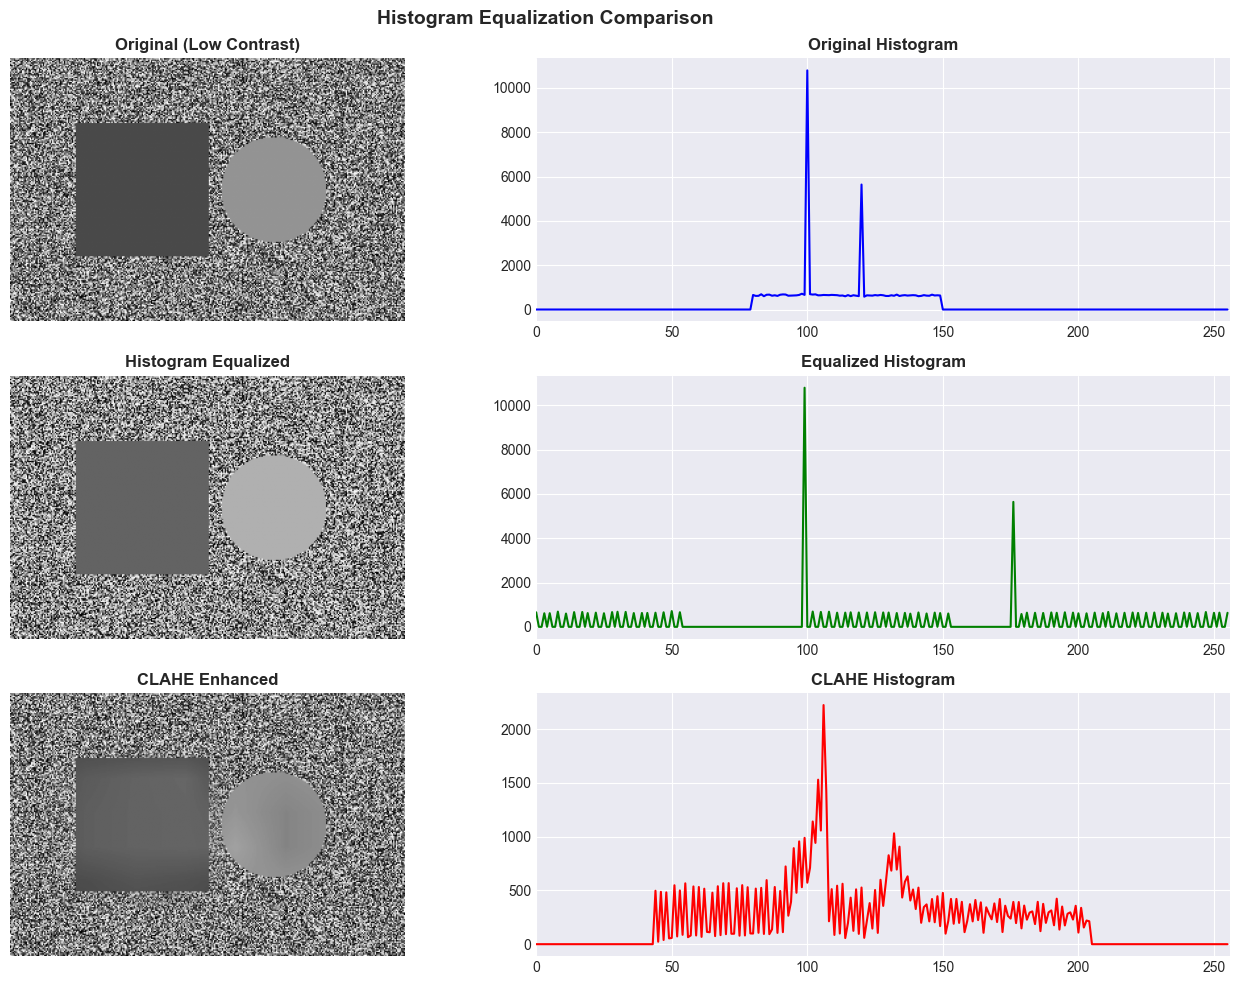

✓ Histogram equalization complete!

Observations:
- Original: Histogram bunched in narrow range (low contrast)
- Equalized: Histogram spread across full range (high contrast)
- CLAHE: More natural enhancement while preserving details


In [5]:
# --- MORNING SESSION: Histogram Visualization ---

# Create low-contrast test image
low_contrast = np.random.randint(80, 150, (200, 300), dtype=np.uint8)
# Add shapes
cv2.rectangle(low_contrast, (50, 50), (150, 150), 100, -1)
cv2.circle(low_contrast, (200, 100), 40, 120, -1)

# Equalize histogram
equalized = cv2.equalizeHist(low_contrast)

# CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_result = clahe.apply(low_contrast)

# Calculate histograms
hist_original = cv2.calcHist([low_contrast], [0], None, [256], [0, 256])
hist_equalized = cv2.calcHist([equalized], [0], None, [256], [0, 256])
hist_clahe = cv2.calcHist([clahe_result], [0], None, [256], [0, 256])

# Visualize
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# Original
axes[0, 0].imshow(low_contrast, cmap='gray')
axes[0, 0].set_title('Original (Low Contrast)', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].plot(hist_original, color='blue', linewidth=1.5)
axes[0, 1].set_title('Original Histogram', fontweight='bold')
axes[0, 1].set_xlim([0, 256])

# Equalized
axes[1, 0].imshow(equalized, cmap='gray')
axes[1, 0].set_title('Histogram Equalized', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].plot(hist_equalized, color='green', linewidth=1.5)
axes[1, 1].set_title('Equalized Histogram', fontweight='bold')
axes[1, 1].set_xlim([0, 256])

# CLAHE
axes[2, 0].imshow(clahe_result, cmap='gray')
axes[2, 0].set_title('CLAHE Enhanced', fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].plot(hist_clahe, color='red', linewidth=1.5)
axes[2, 1].set_title('CLAHE Histogram', fontweight='bold')
axes[2, 1].set_xlim([0, 256])

plt.suptitle('Histogram Equalization Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Histogram equalization complete!")
print("\nObservations:")
print("- Original: Histogram bunched in narrow range (low contrast)")
print("- Equalized: Histogram spread across full range (high contrast)")
print("- CLAHE: More natural enhancement while preserving details")

## 3. Brightness & Contrast Adjustment

**Brightness:** Add or subtract value from all pixels
- Formula: output = input + brightness_value

**Contrast:** Multiply pixel values
- Formula: output = input × contrast_value

**Gamma Correction:** Non-linear brightness adjustment
- Formula: output = input^(1/gamma)
- Gamma < 1: Brighten image
- Gamma > 1: Darken image
- More natural than simple brightness adjustment

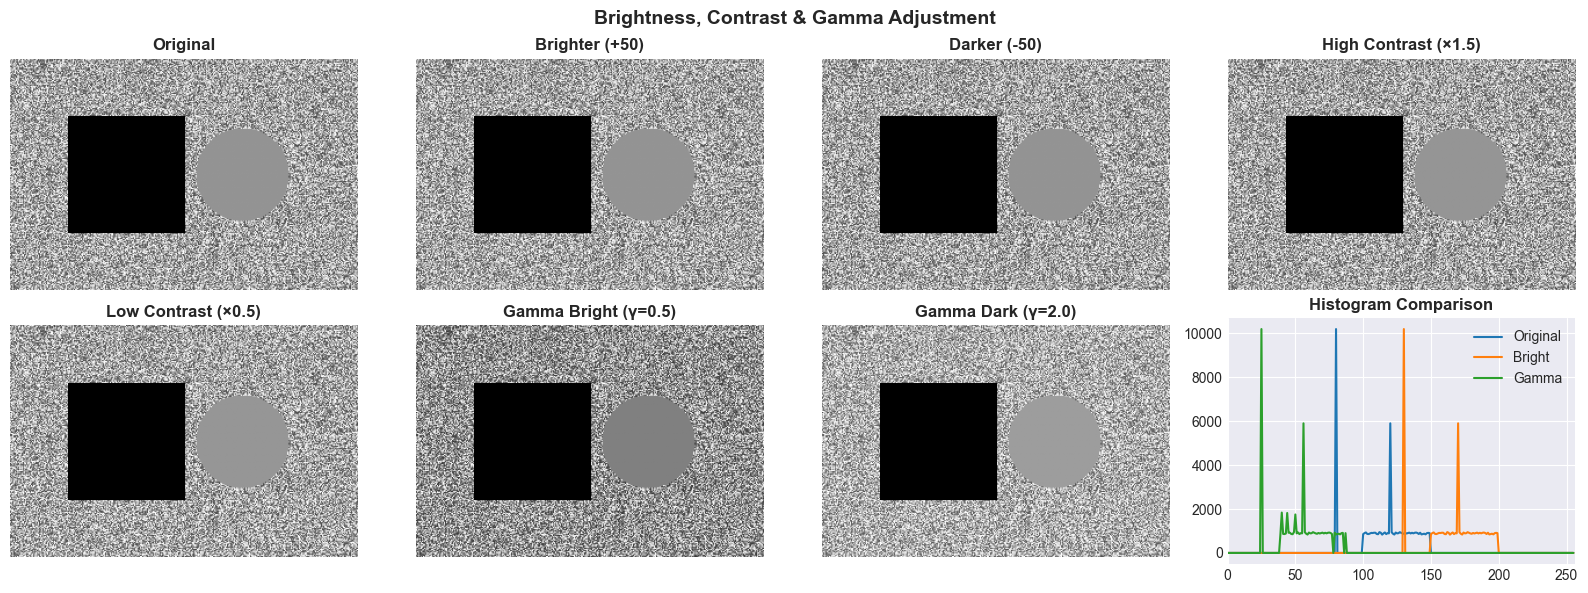

✓ Image enhancement complete!


In [6]:
# --- AFTERNOON SESSION: Brightness, Contrast & Gamma ---

# Create test image
test_img = np.random.randint(100, 150, (200, 300), dtype=np.uint8)
cv2.rectangle(test_img, (50, 50), (150, 150), 80, -1)
cv2.circle(test_img, (200, 100), 40, 120, -1)

# Brightness adjustment
bright = np.clip(test_img.astype(float) + 50, 0, 255).astype(np.uint8)
dark = np.clip(test_img.astype(float) - 50, 0, 255).astype(np.uint8)

# Contrast adjustment
contrast_high = np.clip(test_img.astype(float) * 1.5, 0, 255).astype(np.uint8)
contrast_low = np.clip(test_img.astype(float) * 0.5, 0, 255).astype(np.uint8)

# Gamma correction
def gamma_correction(image, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype(np.uint8)
    return cv2.LUT(image, table)

gamma_bright = gamma_correction(test_img, 0.5)
gamma_dark = gamma_correction(test_img, 2.0)

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

axes[0, 0].imshow(test_img, cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(bright, cmap='gray')
axes[0, 1].set_title('Brighter (+50)', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(dark, cmap='gray')
axes[0, 2].set_title('Darker (-50)', fontweight='bold')
axes[0, 2].axis('off')

axes[0, 3].imshow(contrast_high, cmap='gray')
axes[0, 3].set_title('High Contrast (×1.5)', fontweight='bold')
axes[0, 3].axis('off')

axes[1, 0].imshow(contrast_low, cmap='gray')
axes[1, 0].set_title('Low Contrast (×0.5)', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(gamma_bright, cmap='gray')
axes[1, 1].set_title('Gamma Bright (γ=0.5)', fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(gamma_dark, cmap='gray')
axes[1, 2].set_title('Gamma Dark (γ=2.0)', fontweight='bold')
axes[1, 2].axis('off')

# Show histogram comparison
hist_original = cv2.calcHist([test_img], [0], None, [256], [0, 256])
hist_bright = cv2.calcHist([bright], [0], None, [256], [0, 256])
hist_gamma = cv2.calcHist([gamma_bright], [0], None, [256], [0, 256])

axes[1, 3].plot(hist_original, label='Original', linewidth=1.5)
axes[1, 3].plot(hist_bright, label='Bright', linewidth=1.5)
axes[1, 3].plot(hist_gamma, label='Gamma', linewidth=1.5)
axes[1, 3].set_title('Histogram Comparison', fontweight='bold')
axes[1, 3].legend()
axes[1, 3].set_xlim([0, 256])

plt.suptitle('Brightness, Contrast & Gamma Adjustment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Image enhancement complete!")